In [1]:
import utils_inverse
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for CH<sub>4</sub>

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

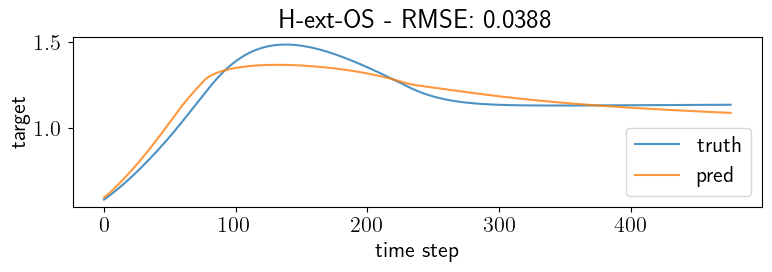

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 2.119370947184507e-06
	||grad CO2||: 0.0
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['CH4']       # Forcing agents included in temperatutre simulations
active_agents = ("CH4",)       # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = 'checkpoints/ch4/baseline_ch4_only.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

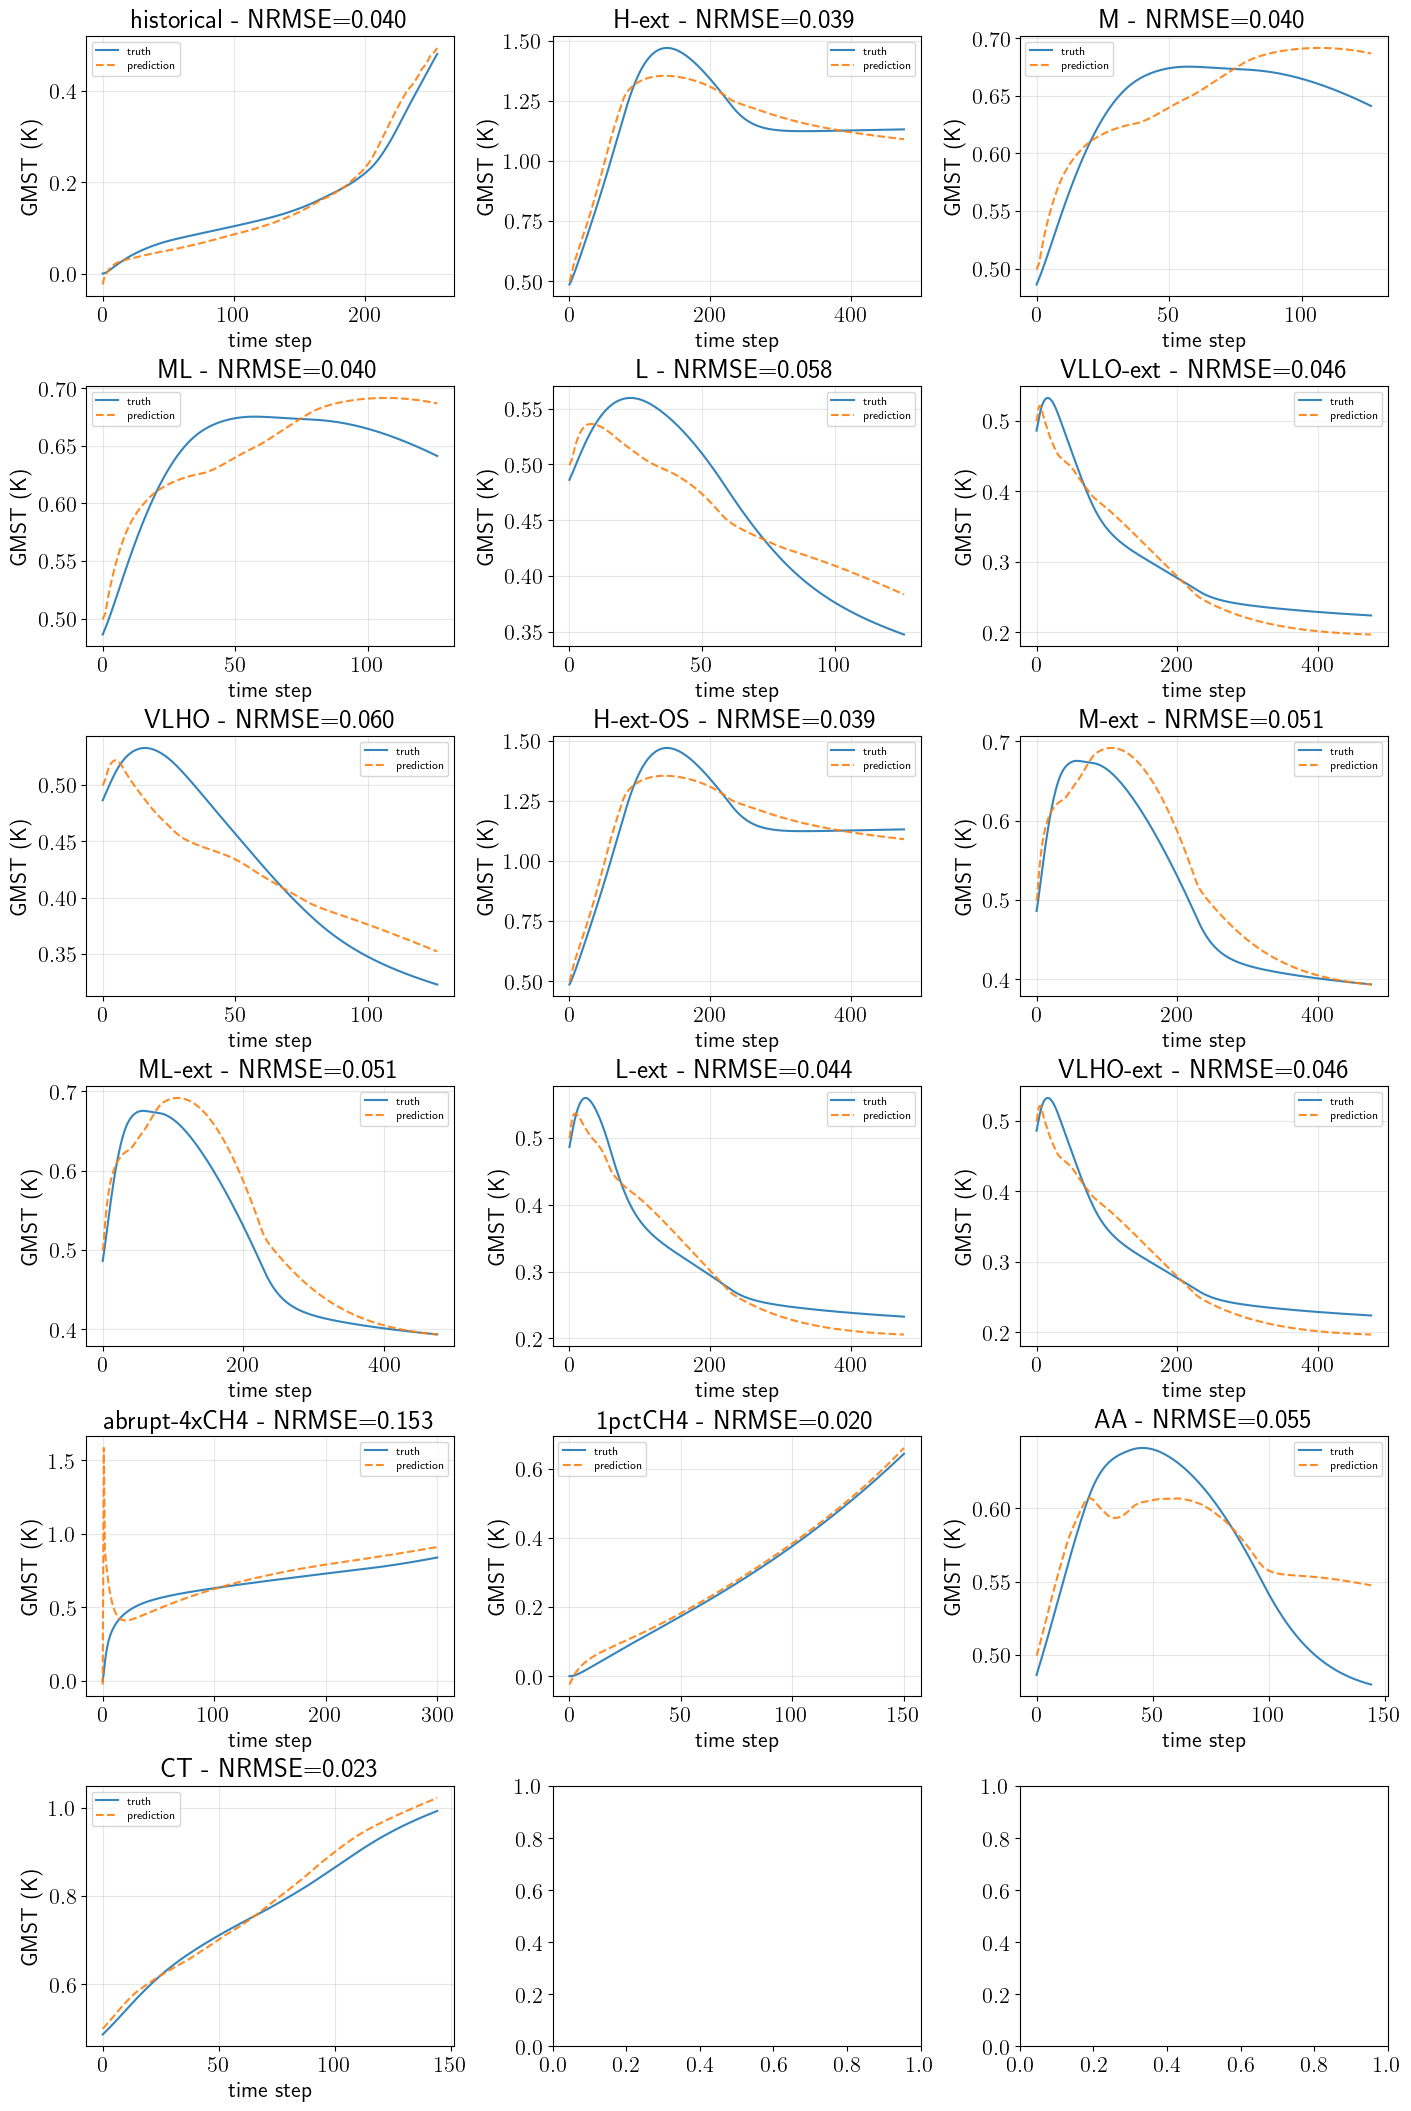

In [5]:
# Optional: plot predictions of baseline emulator
utils_inverse.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize CH<sub>4</sub> emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [7]:
## Create validation data; this is the optimization target
emis_dict_valid                 = {}
emis_dict_valid['H-ext']        = emis_dict_train_JAX['H-ext'].copy()       # High emissions scenario
emis_dict_valid['historical']   = emis_dict_train_JAX['historical'].copy()  # Historical data, required for ScenarioMIP

## Optimization parameters
num_updates     = 1000          # Number of optimization iterations
step_size       = 1e4           # Step size for optimizer, gradients are typically very small
momentum        = 0.9           # Momentum decay rate
nesterov        = True          # Flag to use nesterov momentum in optimization
K_inner         = 400           # Number of gradient descent steps during training
lr_inner        = 5e-2          # Learning rate during training
wd_inner        = 1e-2          # Weight decay (regularization) for training
init_cond       = 'constant'    # Emissions initial condition
T               = 477           # Length of optimized time series
filter_hist     = True          # Flag to not include historical data in the optimization

## Parameters for saving output data
checkpoint_path     = f"checkpoints/ch4/inverse_H-ext_{init_cond}_ch4_only.pkl" # Location of save data
checkpoint_every    = 50    # How often to save snapshots of the optimization
resume_if_exists    = True  # Flag to continue optimization from saved checkpoint, overwrites existing data if False
preds_every         = 50    # How often to save emulator temperature predictions

## Run optimization algorithm
results_CH4_Hext_const = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=num_updates,
    step_size=step_size,
    momentum=momentum,
    nesterov=nesterov,
    K_inner=K_inner,
    lr_inner=lr_inner,
    wd_inner=wd_inner,
    active_agents=active_agents,
    init_cond=init_cond,
    T=T,
    filter_hist=filter_hist,
    checkpoint_path=checkpoint_path,
    checkpoint_every=checkpoint_every,
    resume_if_exists=resume_if_exists,
    preds_every=preds_every,
)

Resuming from checkpoint...


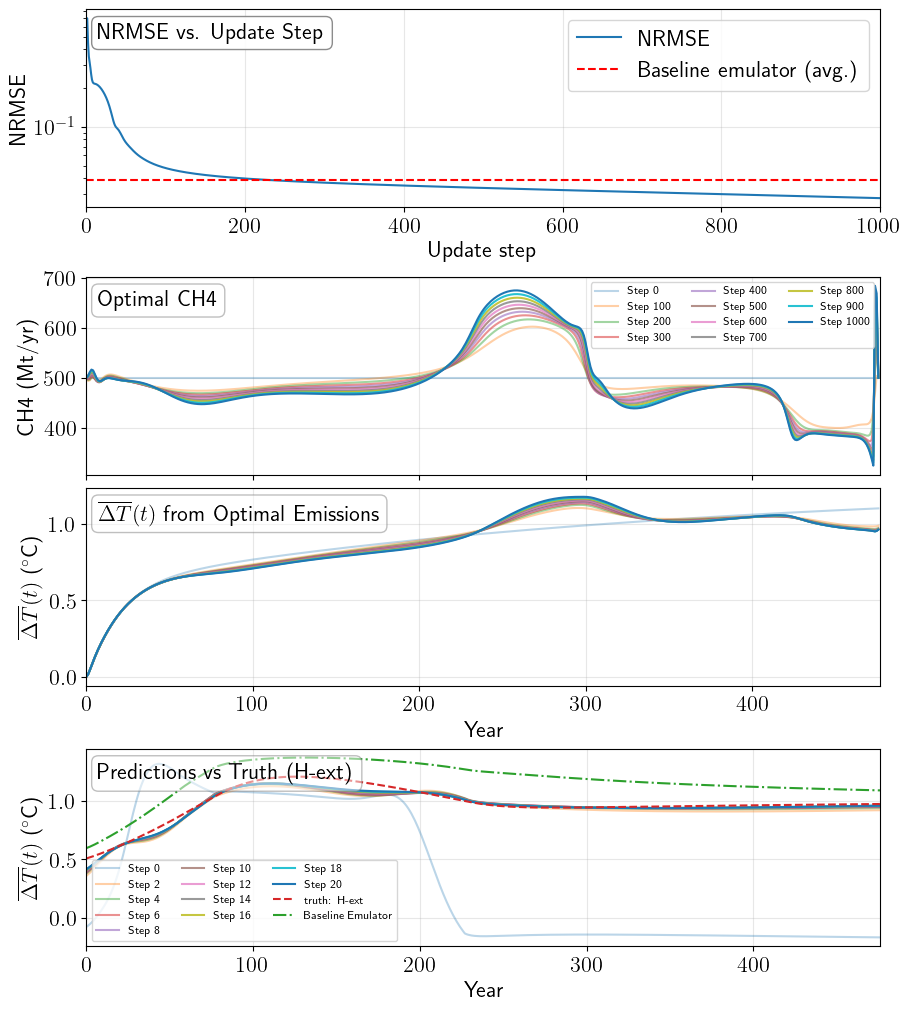

In [8]:
# Optional: plot results of optimization
predict_plot = 'H-ext'

utils_inverse.plot_inverse_results(
    results_CH4_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [29]:
## Create validation data; this is the optimization target
# Here, we optimize over several sets of scenarios
emis_dicts_valid = [(emis_dict_all_JAX.copy(), 'all'),
                    (emis_dict_tier2_JAX.copy(), 'tier2'),
                    (emis_dict_DECK_JAX.copy(), 'DECK'),
                    (emis_dict_CS3_JAX.copy(), 'CS3'),
                    (emis_dict_all_JAX.copy(), 'all')]
results_CH4_dict = {}

## Optimization parameters
num_updates       = 1000          # Number of optimization iterations
step_size         = 1e5           # Step size for optimizer, gradients are typically very small
momentum          = 0.9           # Momentum decay rate
nesterov          = True          # Flag to use nesterov momentum in optimization
K_inner           = 400           # Number of gradient descent steps during training
lr_inner          = 5e-2          # Learning rate during training
wd_inner          = 1e-2          # Weight decay (regularization) for training
init_cond         = 'constant'    # Emissions initial condition
T                 = 751           # Length of optimized time series
smoothness_weight = 1e-5          # Penalty to prevent sharp gradients in the resulting time series

## Parameters for saving output data
checkpoint_every    = 50    # How often to save snapshots of the optimization
resume_if_exists    = False  # Flag to continue optimization from saved checkpoint, overwrites existing data if False
preds_every         = 50    # How often to save emulator temperature predictions

## Run optimization algorithm
for emis_dict, group in emis_dicts_valid:
  print(f'Optimizing over {group}')

  # Historical scenario only counted as part of tier 1
  if group in ['tier2','CS3']:
    filter_hist = True # Flag to not include historical data in the optimization
  else:
    filter_hist = False

  # Location of save data changes for each set of scenarios
  checkpoint_path = f"checkpoints/ch4/inverse_{init_cond}_{group}_ch4_only.pkl"

  results_CH4_dict[group] = utils_inverse.optimize_emissions_inverse(
      emis_dict=emis_dict,
      params0=params0,
      num_updates=num_updates,
      step_size=step_size,
      momentum=momentum,
      nesterov=nesterov,
      K_inner=K_inner,
      lr_inner=lr_inner,
      wd_inner=wd_inner,
      active_agents=active_agents,
      init_cond=init_cond,
      T=T,
      filter_hist=filter_hist,
      checkpoint_path=checkpoint_path,
      checkpoint_every=checkpoint_every,
      resume_if_exists=resume_if_exists,
      preds_every=preds_every,
  )
  break

Optimizing over all
Overwriting save data...


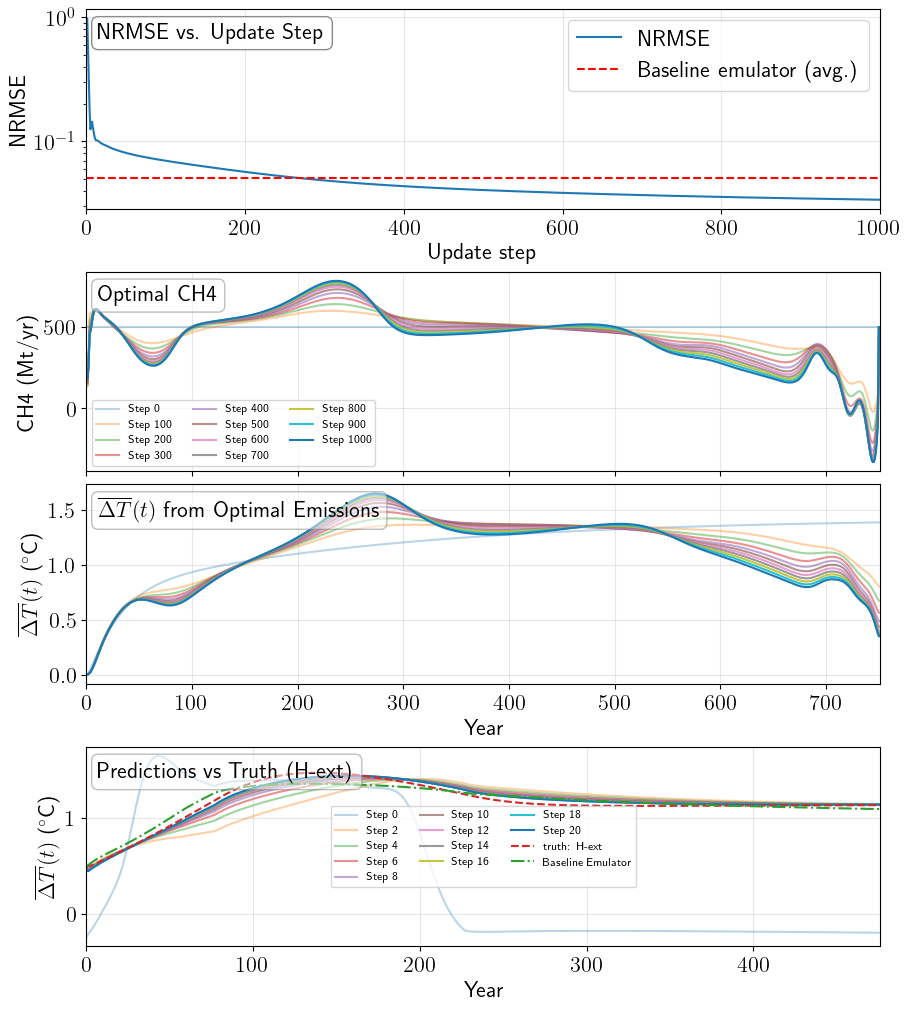

In [30]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'all'  # Evaluation set to plot optimized results for
baseline_test   = 'All' # Evaluation set to plot results for
predict_plot    = 'H-ext'  # Individual scenario to plot predictions

utils_inverse.plot_inverse_results(
    results_CH4_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)

In [21]:
baseline_results['All']

{'historical': Array(0.04042482, dtype=float32),
 'H-ext': Array(0.03932647, dtype=float32),
 'M': Array(0.03995804, dtype=float32),
 'ML': Array(0.03995804, dtype=float32),
 'L': Array(0.05790954, dtype=float32),
 'VLLO-ext': Array(0.04561222, dtype=float32),
 'VLHO': Array(0.05964759, dtype=float32),
 'H-ext-OS': Array(0.03932647, dtype=float32),
 'M-ext': Array(0.05140524, dtype=float32),
 'ML-ext': Array(0.05140524, dtype=float32),
 'L-ext': Array(0.04435604, dtype=float32),
 'VLHO-ext': Array(0.04561222, dtype=float32),
 'abrupt-4xCH4': Array(0.15255606, dtype=float32),
 '1pctCH4': Array(0.01993449, dtype=float32),
 'AA': Array(0.05499809, dtype=float32),
 'CT': Array(0.02262766, dtype=float32),
 'mean': np.float64(0.05094799070443162)}

In [22]:
opt_test = 'all'
weights, errors = [], []
for i in range(16):
  name, yhat, ytrue = results_CH4_dict[opt_test]['preds_traj'][-1][i]
  errors.append(utils_inverse._nrmse(yhat, ytrue))
  print(name, errors[-1])
  weights.append(len(yhat))
import numpy as np
print(np.average(errors, weights=weights))

historical 0.16182058
H-ext 0.12430173
M 0.032160006
ML 0.032160006
L 0.037228033
VLLO-ext 0.02195767
VLHO 0.037860986
H-ext-OS 0.12430173
M-ext 0.06831137
ML-ext 0.06831137
L-ext 0.02048526
VLHO-ext 0.02195767
abrupt-4xCH4 0.15422572
1pctCH4 0.08925082
AA 0.0369252
CT 0.056370366
0.07162635141158989
